In [ ]:
!pip install -q SoccerNet roboflow ultralytics dagshub mlflow paddleocr
!python -m pip install -q paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!pip install -q --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273

In [ ]:
#!python -m pip install -q paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
#!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 4. Install PaddleOCR
#!pip install "paddleocr>=2.8"

In [ ]:
import sys


if 'paddle' not in sys.modules:
    import paddle
    print(f"Paddle Version: {paddle.__version__}")


    gpu_available = paddle.device.is_compiled_with_cuda()
    print(f"GPU Available for Paddle: {gpu_available}")

    if gpu_available:
        paddle.device.set_device('gpu')
        print("🚀 Successfully bound PaddlePaddle to the GPU!")
else:
    print("Paddle is already loaded in memory, bypassing to prevent initialization conflicts.")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle Version: 3.2.0
GPU Available for Paddle: True
🚀 Successfully bound PaddlePaddle to the GPU!


In [ ]:
# CPU version
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# GPU version, requires driver version >= 450.80.02 (Linux) or >= 452.39 (Windows)
#python -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/

# GPU version, requires driver version >= 550.54.14 (Linux) or >= 550.54.14 (Windows)
#!python -m pip install -q paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/

!python -c "import paddle; print(paddle.__version__)"

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
3.2.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def cluster_player_teams_from_crops(player_data, resize_dim=(64, 64)):

    if not player_data:
        return []

    feature_list = []
    valid_players = []


    for player in player_data:
        crop = player['crop']

        if crop is None or crop.size == 0:
            continue
        height, width, _ = crop.shape
        torso_crop = crop[0:int(height * 0.6), :]

        if torso_crop.size == 0:
            continue
        resized = cv2.resize(torso_crop, resize_dim)
        hsv_resized = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
        flattened_features = hsv_resized.flatten()
        feature_list.append(flattened_features)
        valid_players.append(player)

    if not feature_list:
        return player_data
    feature_matrix = np.array(feature_list)

    kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(feature_matrix)

    for idx, player in enumerate(valid_players):
        player['team_cluster'] = int(cluster_labels[idx])

    return valid_players

def extract_player_crops(yolo_results, frame, player_class_id=1):

    player_data = []

    if yolo_results is None or yolo_results.boxes is None:
        return player_data
    boxes = yolo_results.boxes
    frame_h, frame_w = frame.shape[:2]
    for i in range(len(boxes)):
        if boxes.id is None:
            continue
        cls_id = int(boxes.cls[i].item())
        if cls_id != player_class_id:
            continue

        track_id = int(boxes.id[i].item())
        x1, y1, x2, y2 = boxes.xyxy[i].cpu().numpy().astype(int)

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(frame_w, x2)
        y2 = min(frame_h, y2)

        crop = frame[y1:y2, x1:x2]
        if crop.size > 0:
            player_data.append({
                'id': track_id,
                'bbox': [x1, y1, x2, y2],
                'crop': crop
            })

    return player_data
def assign_teams_by_anchor(players_crop, resize_dim=(64, 64), anchors=None):
    if not players_crop:
        return [], anchors

    feature_list = []
    valid_players = []
    for player in players_crop:
        crop = player['crop']
        if crop is None or crop.size == 0:
            continue
        height, width, _ = crop.shape
        torso_crop = crop[0:int(height * 0.6), :]

        if torso_crop.size == 0:
            continue

        resized = cv2.resize(torso_crop, resize_dim)
        hsv_resized = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
        flattened_features = hsv_resized.flatten()

        feature_list.append(flattened_features)
        valid_players.append(player)

    if not feature_list:
        return players_crop, anchors

    feature_matrix = np.array(feature_list)

    if anchors is None:
        print("Automatically initializing team color anchors from the first frame...")
        kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(feature_matrix)

        anchors = kmeans.cluster_centers_

        for idx, player in enumerate(valid_players):
            player['team_cluster'] = int(cluster_labels[idx])

    else:
        for player_idx, feature_vector in enumerate(feature_matrix):
            dist_to_team_0 = np.linalg.norm(feature_vector - anchors[0])
            dist_to_team_1 = np.linalg.norm(feature_vector - anchors[1])
            assigned_team = 0 if dist_to_team_0 < dist_to_team_1 else 1
            valid_players[player_idx]['team_cluster'] = assigned_team

    return valid_players, anchors


In [ ]:
from ultralytics import YOLO
model = YOLO("https://github.com/AgabaEmbedded/Soccer-Tracking/releases/download/1.0/best-large-image.pt")
pmodel = YOLO("https://github.com/AgabaEmbedded/Soccer-Tracking/releases/download/1.1/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from paddleocr import PaddleOCR
from paddleocr import TextRecognition
from paddleocr import TextDetection

#ocr = PaddleOCR(use_angle_cls=False, lang="en",)#, det=False)#, show_log=False)
ocr = TextRecognition(engine="paddle", model_name="en_PP-OCRv5_mobile_rec")

#detect_ocr = TextDetection(engine="paddle")
TEAM_ANCHORS = None
TRACK_IDENTITY_VOTES = {}
back_region_list = []

CLASS_COLORS = {0: (0, 0, 255), 1: (255, 255, 0), 3: (0, 255, 255)}
TEAM_COLORS = {0: (255, 0, 0), 1: (0, 255, 0)}

results = model.track("/content/drive/MyDrive/test/test_video_116.mp4",
                      save=False,
                      imgsz=[1920, 1088],
                      conf=0.25,
                      iou=0.45,
                      batch=1,
                      stream=True,
                      verbose=False,
                      tracker="botsort.yaml")

video_writer = None
# Initialize a more secure, team-aware voting database
# Structure: { team_id: { track_id: { "jersey_num": accumulated_weight } } }
if 'TEAM_TRACK_VOTES' not in globals():
    TEAM_TRACK_VOTES = {0: {}, 1: {}}

# Global registry to ensure a jersey number isn't assigned to two active tracks on the same team
# Structure: { team_id: { "jersey_num": track_id } }
ACTIVE_TEAM_ASSIGNMENTS = {0: {}, 1: {}}

# Inside your tracking loop...
for result in results:
    result = result.cpu()
    if result.boxes is None or len(result.boxes) == 0:
        continue

    annotated_frame = result.orig_img.copy()

    if video_writer is None:
        h, w = annotated_frame.shape[:2]
        video_writer = cv2.VideoWriter('/content/output_tracked_match.mp4',
                                       cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))

    players_crop = extract_player_crops(result, result.orig_img, player_class_id=2)

    team_map = {}
    if players_crop:
        players_crop, TEAM_ANCHORS = assign_teams_by_anchor(players_crop, resize_dim=(64, 64), anchors=TEAM_ANCHORS)

        for player in players_crop:
            track_id = player['id']
            crop_img = player['crop']
            team_id = player.get('team_cluster', None)
            team_map[track_id] = team_id

            # Skip OCR entirely if team clustering didn't resolve a valid cluster (0 or 1)
            if team_id not in [0, 1]:
                continue

            h_crop, w_crop, _ = crop_img.shape
            back_region = crop_img[int(h_crop * 0.15):int(h_crop * 0.55), :]

            if back_region.size > 0:
                ocr_result = ocr.predict(back_region)

                if ocr_result and len(ocr_result) > 0:
                    res = ocr_result[0]
                    detected_text = res.get('rec_text', '') if isinstance(res, dict) else getattr(res, 'rec_text', '')
                    confidence = res.get('rec_score', 0.0) if isinstance(res, dict) else getattr(res, 'rec_score', 0.0)

                    if detected_text:
                        digit_string = "".join([char for char in str(detected_text) if char.isdigit()])

                        # Raise confidence bar to filter out minor fabric wrinkles
                        if digit_string and confidence > 0.80:
                            if track_id not in TEAM_TRACK_VOTES[team_id]:
                                TEAM_TRACK_VOTES[team_id][track_id] = {}

                            # Evidential Weighting: Add the actual model confidence as the vote weight
                            # This means one clear 98% read beats three blurry 65% noise reads
                            TEAM_TRACK_VOTES[team_id][track_id][digit_string] = \
                                TEAM_TRACK_VOTES[team_id][track_id].get(digit_string, 0.0) + confidence

    # --- Frame Annotation and Multi-Class Identity Resolution ---
    boxes = result.boxes
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i].item())
        x1, y1, x2, y2 = boxes.xyxy[i].numpy().astype(int)

        if cls_id == 2:
            track_id = int(boxes.id[i].item()) if boxes.id is not None else None
            team_id = team_map.get(track_id, None)
            color = TEAM_COLORS.get(team_id, (255, 255, 255))

            resolved_jersey = "Unconfirmed"

            # Verify the track exists within our team-isolated voting framework
            if team_id in [0, 1] and track_id in TEAM_TRACK_VOTES[team_id]:
                votes = TEAM_TRACK_VOTES[team_id][track_id]
                if votes:
                    # Find the highest-weighted jersey number candidate
                    candidate_jersey = max(votes, key=votes.get)
                    candidate_weight = votes[candidate_jersey]

                    # Statistical Safeguard: Only confirm if the candidate has accumulated enough evidence
                    # e.g., requires an accumulated confidence weight equivalent to roughly 3-4 highly confident frames
                    if candidate_weight > 3.0:
                        resolved_jersey = candidate_weight

                        # Double-Jersey Collision Prevention: Ensure this number isn't already stolen by another active track on this team
                        current_owner = ACTIVE_TEAM_ASSIGNMENTS[team_id].get(candidate_jersey, None)
                        if current_owner is None or current_owner == track_id:
                            ACTIVE_TEAM_ASSIGNMENTS[team_id][candidate_jersey] = track_id
                            resolved_jersey = candidate_jersey
                        else:
                            # Conflict! If another active track owns it, mark as unconfirmed to prevent duplicates on the pitch
                            resolved_jersey = "Sorting..."

            label = f"Player {resolved_jersey} | Team {team_id if team_id is not None else 'N/A'}"

        else:
            color = CLASS_COLORS.get(cls_id, (255, 255, 255))
            label_names = {0: "Ball", 1: "Goalkeeper", 3: "Referee"}
            track_str = f" ID: {int(boxes.id[i].item())}" if boxes.id is not None else ""
            label = f"{label_names.get(cls_id, 'Unknown')}{track_str}"

        # Draw box and labels
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 3)
        label_size, base_line = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        y1_label = max(y1, label_size[1] + 10)
        cv2.rectangle(annotated_frame, (x1, y1_label - label_size[1] - 5), (x1 + label_size[0], y1_label + base_line), color, cv2.FILLED)
        cv2.putText(annotated_frame, label, (x1, y1_label - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

    video_writer.write(annotated_frame)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this s

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 180ms
Prepared 1 package in 28ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Automatically initializing team color anchors from the first frame...


In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from paddleocr import TextRecognition

# Initialize your specialized v5 mobile english engine
ocr = TextRecognition(engine="paddle", model_name="en_PP-OCRv5_mobile_rec")

TEAM_ANCHORS = None
CLASS_COLORS = {0: (0, 0, 255), 1: (255, 255, 0), 3: (0, 255, 255)}
TEAM_COLORS = {0: (255, 0, 0), 1: (0, 255, 0)}

# Explicitly wipe out state to clear historical noise or background memory locks
TEAM_TRACK_VOTES = {0: {}, 1: {}}
ACTIVE_TEAM_ASSIGNMENTS = {0: {}, 1: {}}

results = model.track("/content/drive/MyDrive/test/test_video_116.mp4",
                      save=False,
                      imgsz=[1920, 1088],
                      conf=0.25,
                      iou=0.45,
                      batch=32,   # Set back to your high-performance value
                      stream=True,
                      verbose=False,
                      tracker="botsort.yaml")

video_writer = None

try:  # Safety Anchor: Prevents corruption if the cell crashes or is interrupted
    for result in results:
        result = result.cpu()
        if result.boxes is None or len(result.boxes) == 0:
            continue

        annotated_frame = result.orig_img.copy()

        if video_writer is None:
            h, w = annotated_frame.shape[:2]
            # Swapped to standard container mapping for absolute VLC cross-platform validation
            video_writer = cv2.VideoWriter('/content/output_tracked_match.mp4',
                                           cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))

        players_crop = extract_player_crops(result, result.orig_img, player_class_id=2)

        team_map = {}
        if players_crop:
            players_crop, TEAM_ANCHORS = assign_teams_by_anchor(players_crop, resize_dim=(64, 64), anchors=TEAM_ANCHORS)

            for player in players_crop:
                track_id = player['id']
                crop_img = player['crop']
                team_id = player.get('team_cluster', None)
                team_map[track_id] = team_id

                if team_id not in [0, 1]:
                    continue

                h_crop, w_crop, _ = crop_img.shape
                back_region = crop_img[int(h_crop * 0.15):int(h_crop * 0.55), :]

                if back_region.size > 0:
                    ocr_result = ocr.predict(back_region)

                    if ocr_result and len(ocr_result) > 0:
                        res = ocr_result[0]
                        detected_text = res.get('rec_text', '') if isinstance(res, dict) else getattr(res, 'rec_text', '')
                        confidence = res.get('rec_score', 0.0) if isinstance(res, dict) else getattr(res, 'rec_score', 0.0)

                        if detected_text:
                            digit_string = "".join([char for char in str(detected_text) if char.isdigit()])

                            if digit_string and confidence > 0.80:
                                if track_id not in TEAM_TRACK_VOTES[team_id]:
                                    TEAM_TRACK_VOTES[team_id][track_id] = {}

                                TEAM_TRACK_VOTES[team_id][track_id][digit_string] = \
                                    TEAM_TRACK_VOTES[team_id][track_id].get(digit_string, 0.0) + confidence

        # --- Frame Annotation Phase ---
        boxes = result.boxes
        for i in range(len(boxes)):
            cls_id = int(boxes.cls[i].item())
            x1, y1, x2, y2 = boxes.xyxy[i].numpy().astype(int)

            if cls_id == 2:
                track_id = int(boxes.id[i].item()) if boxes.id is not None else None
                team_id = team_map.get(track_id, None)
                color = TEAM_COLORS.get(team_id, (255, 255, 255))

                resolved_jersey = "Unconfirmed"

                if team_id in [0, 1] and track_id in TEAM_TRACK_VOTES[team_id]:
                    votes = TEAM_TRACK_VOTES[team_id][track_id]
                    if votes:
                        candidate_jersey = max(votes, key=votes.get)
                        candidate_weight = votes[candidate_jersey]

                        if candidate_weight > 3.0:
                            # FIXED TYPO HERE: Ensure it points to the string code value instead of the float weight
                            resolved_jersey = candidate_jersey

                            current_owner = ACTIVE_TEAM_ASSIGNMENTS[team_id].get(candidate_jersey, None)
                            if current_owner is None or current_owner == track_id:
                                ACTIVE_TEAM_ASSIGNMENTS[team_id][candidate_jersey] = track_id
                            else:
                                resolved_jersey = "Sorting..."

                label = f"Player {resolved_jersey} | Team {team_id if team_id is not None else 'N/A'}"

            else:
                color = CLASS_COLORS.get(cls_id, (255, 255, 255))
                label_names = {0: "Ball", 1: "Goalkeeper", 3: "Referee"}
                track_str = f" ID: {int(boxes.id[i].item())}" if boxes.id is not None else ""
                label = f"{label_names.get(cls_id, 'Unknown')}{track_str}"

            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 3)
            label_size, base_line = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            y1_label = max(y1, label_size[1] + 10)
            cv2.rectangle(annotated_frame, (x1, y1_label - label_size[1] - 5), (x1 + label_size[0], y1_label + base_line), color, cv2.FILLED)
            cv2.putText(annotated_frame, label, (x1, y1_label - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

        video_writer.write(annotated_frame)

finally:
    # This block executes no matter what, forcing OpenCV to close and finalize the MP4 metadata index safely
    if video_writer is not None:
        video_writer.release()
        print("🔒 VideoWriter safely finalized and saved to disk.")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Automatically initializing team color anchors from the first frame...
🔒 VideoWriter safely finalized and saved to disk.


In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from paddleocr import PaddleOCR
from paddleocr import TextRecognition
from paddleocr import TextDetection

#ocr = PaddleOCR(use_angle_cls=False, lang="en",)#, det=False)#, show_log=False)
ocr = TextRecognition(engine="paddle", model_name="en_PP-OCRv5_mobile_rec")

#detect_ocr = TextDetection(engine="paddle")
TEAM_ANCHORS = None
TRACK_IDENTITY_VOTES = {}
back_region_list = []

CLASS_COLORS = {0: (0, 0, 255), 1: (255, 255, 0), 3: (0, 255, 255)}
TEAM_COLORS = {0: (255, 0, 0), 1: (0, 255, 0)}

results = model.track("/content/drive/MyDrive/test/test_video_116.mp4",
                      save=False,
                      imgsz=[1920, 1088],
                      conf=0.25,
                      iou=0.45,
                      batch=32,
                      stream=True,
                      verbose=False,
                      tracker="botsort.yaml")

video_writer = None

for index, result in enumerate(results):
    result = result.cpu()
    if result.boxes is None or len(result.boxes) == 0:
        continue

    annotated_frame = result.orig_img.copy()

    if video_writer is None:
        h, w = annotated_frame.shape[:2]
        video_writer = cv2.VideoWriter('/content/output_tracked_match.mp4',
                                       cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))

    players_crop = extract_player_crops(result, result.orig_img, player_class_id=2)

    team_map = {}
    if players_crop:
        players_crop, TEAM_ANCHORS = assign_teams_by_anchor(players_crop, resize_dim=(64, 64), anchors=TEAM_ANCHORS)

        for player in players_crop:
            track_id = player['id']
            crop_img = player['crop']
            team_map[track_id] = player.get('team_cluster', None)

            h_crop, w_crop, _ = crop_img.shape
            back_region = crop_img[int(h_crop * 0.15):int(h_crop * 0.55), :]
            #detection_output = detect_ocr.predict(back_region, batch_size=1)

            #if len(detection_output[0]["dt_polys"]) == 0:
            #    continue




            if back_region.size > 0:
                ocr_result = ocr.predict(back_region)

                if ocr_result and len(ocr_result) > 0:


                    res = ocr_result[0]

                    #if index%10 == 0:
                    #  plt.imshow(back_region)
                    #  plt.show()
                    #  print(res["rec_text"])

                    detected_text = res.get('rec_text', '') if isinstance(res, dict) else getattr(res, 'rec_text', '')
                    confidence = res.get('rec_score', 0.0) if isinstance(res, dict) else getattr(res, 'rec_score', 0.0)

                    if detected_text:
                        digit_string = "".join([char for char in str(detected_text) if char.isdigit()])

                        if digit_string and confidence > 0.80:
                            if track_id not in TRACK_IDENTITY_VOTES:
                                TRACK_IDENTITY_VOTES[track_id] = {}

                            TRACK_IDENTITY_VOTES[track_id][digit_string] = TRACK_IDENTITY_VOTES[track_id].get(digit_string, 0) + 1

    boxes = result.boxes
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i].item())
        x1, y1, x2, y2 = boxes.xyxy[i].numpy().astype(int)

        if cls_id == 2:
            track_id = int(boxes.id[i].item()) if boxes.id is not None else None
            team_id = team_map.get(track_id, None)
            color = TEAM_COLORS.get(team_id, (255, 255, 255))


            resolved_jersey = "Unconfirmed"
            if track_id in TRACK_IDENTITY_VOTES and TRACK_IDENTITY_VOTES[track_id]:

                resolved_jersey = max(TRACK_IDENTITY_VOTES[track_id], key=TRACK_IDENTITY_VOTES[track_id].get)

            label = f"Player {resolved_jersey}|{track_id} | Team {team_id if team_id is not None else 'N/A'}"

        else:
            color = CLASS_COLORS.get(cls_id, (255, 255, 255))
            label_names = {0: "Ball", 1: "Goalkeeper", 3: "Referee"}
            track_str = f" ID: {int(boxes.id[i].item())}" if boxes.id is not None else ""
            label = f"{label_names.get(cls_id, 'Unknown')}{track_str}"

        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 3)
        label_size, base_line = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        y1_label = max(y1, label_size[1] + 10)
        cv2.rectangle(annotated_frame, (x1, y1_label - label_size[1] - 5), (x1 + label_size[0], y1_label + base_line), color, cv2.FILLED)
        cv2.putText(annotated_frame, label, (x1, y1_label - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

    video_writer.write(annotated_frame)
    #if index == 100:
    #  break

if video_writer is not None:
    video_writer.release()
    print("🚀 Tracking video complete with Team and OCR resolution configurations!")

In [ ]:
import cv2
import os
import glob

def frames_to_video(images_dir, output_video_path, fps=25):
    # Grab all jpeg images and sort them numerically so the video plays in order
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))

    if not image_files:
        print(f"No images found in {images_dir}")
        return

    # Read the first image to dynamically extract widescreen dimensions
    first_frame = cv2.imread(image_files[0])
    height, width, layers = first_frame.shape

    # Initialize the video writer with the MP4V codec
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"Stitching {len(image_files)} frames into {output_video_path}...")
    for image_file in image_files:
        frame = cv2.imread(image_file)
        video.write(frame)

    video.release()
    print("Video compilation complete!")

# Usage: Point to one of your downloaded sequence image directories
images_input = "/content/drive/MyDrive/test/SNMOT-116/img1"
video_output = "test_video_116.mp4"

frames_to_video(images_input, video_output, fps=60)

Stitching 750 frames into test_video_116.mp4...
Video compilation complete!


/tmp/ipykernel_5264/414851252.py:9: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=False, lang="en")#, det=False, show_log=False)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directo

Automatically initializing team color anchors from the first frame...


/tmp/ipykernel_5264/414851252.py:64: DeprecationWarning: Please use `predict` instead.
  ocr_result = ocr.ocr(back_region)#, cls=False)


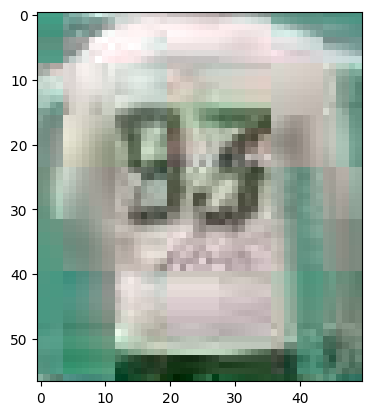

['26']


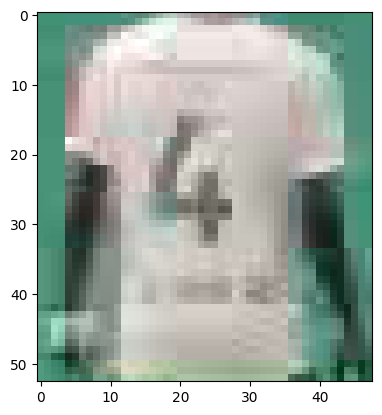

['区']


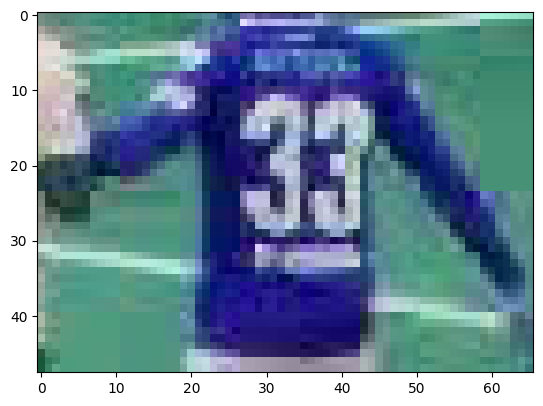

['33']


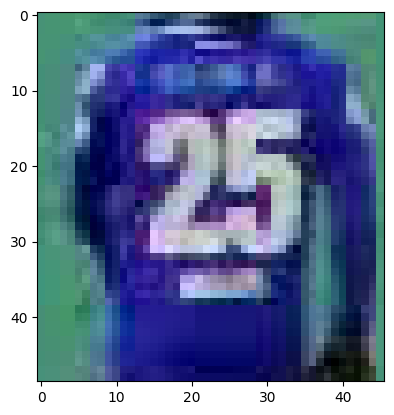

['25']


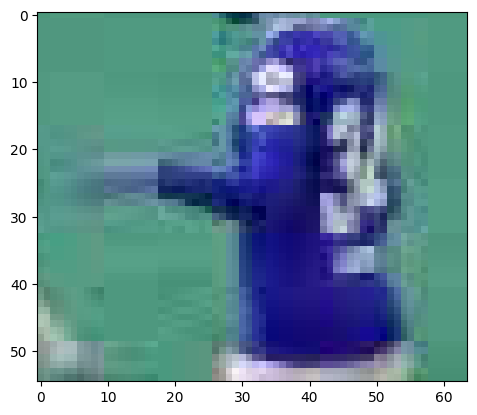

['王']


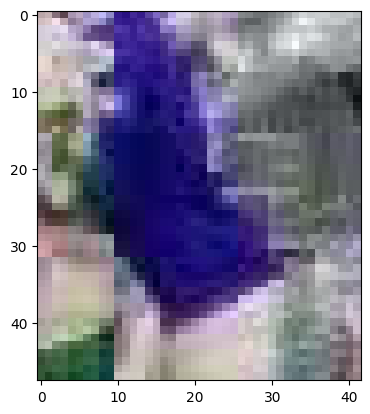

['L']


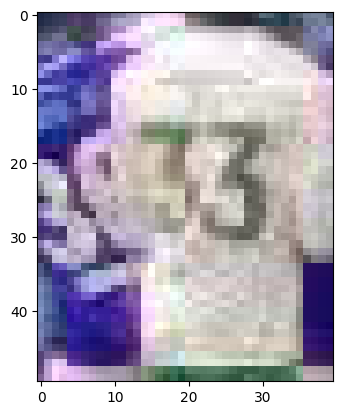

['25']


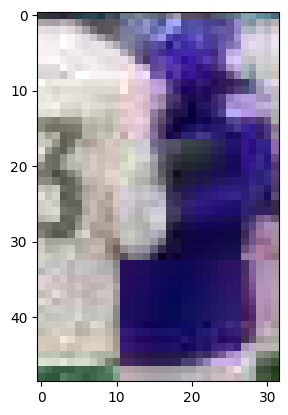

['机']
🚀 Tracking video complete with Team and OCR resolution configurations!


In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from paddleocr import PaddleOCR

# --- 1. Initialize PaddleOCR ---
# lang="en" uses standard Latin characters/digits.
# det=False bypasses the text localization network since we are ALREADY cropping the player torso!
ocr = PaddleOCR(use_angle_cls=False, lang="en")#, det=False, show_log=False)

# --- 2. Global Registries for Tracking Consistency ---
TEAM_ANCHORS = None      # Stores K-Means cluster color centers
TRACK_IDENTITY_VOTES = {} # Dictionary structure: { track_id: { "7": 12, "10": 1 } }

# Define Drawing Colors (BGR)
CLASS_COLORS = {0: (0, 0, 255), 1: (255, 255, 0), 3: (0, 255, 255)}
TEAM_COLORS = {0: (255, 0, 0), 1: (0, 255, 0)}

# --- 3. Run YOLO Track Loop with Custom GMC Config ---
results = model.track("/content/test_video_116.mp4",
                      save=False,
                      imgsz=[1920, 1088],
                      conf=0.25,
                      iou=0.45,
                      batch=1,
                      stream=True,
                      verbose=False,
                      tracker="botsort.yaml") # Re-ID off, Motion + GMC active

video_writer = None

for result in results:
    result = result.cpu()
    if result.boxes is None or len(result.boxes) == 0:
        continue

    annotated_frame = result.orig_img.copy()

    if video_writer is None:
        h, w = annotated_frame.shape[:2]
        video_writer = cv2.VideoWriter('/content/output_tracked_match.mp4',
                                       cv2.VideoWriter_fourcc(*'mp4v'), 25, (w, h))

    # Extract crops for active players (Class 2)
    players_crop = extract_player_crops(result, result.orig_img, player_class_id=2)

    team_map = {}
    if players_crop:
        # Run Team Anchor Matching Loop
        players_crop, TEAM_ANCHORS = assign_teams_by_anchor(players_crop, resize_dim=(64, 64), anchors=TEAM_ANCHORS)

        # --- 4. PaddleOCR Digit Extraction & Voting Loop ---
        for player in players_crop:
            track_id = player['id']
            crop_img = player['crop']
            team_map[track_id] = player.get('team_cluster', None)

            # Focus strictly on the mid-upper back region where jersey numbers live
            h_crop, w_crop, _ = crop_img.shape
            back_region = crop_img[int(h_crop * 0.15):int(h_crop * 0.55), :]

            if back_region.size > 0:
                # Pass the raw image matrix directly into PaddleOCR
                ocr_result = ocr.ocr(back_region)#, cls=False)

                if ocr_result and ocr_result[0]["rec_texts"]:
                    # Extract string text and confidence score
                    detected_text, confidence = ocr_result[0]["rec_texts"][0], ocr_result[0]["rec_scores"][0]
                    plt.imshow(back_region)
                    plt.show()
                    print(ocr_result[0]["rec_texts"])

                    # Clean the string to keep only digits (filters out wrinkles mistaken for letters)
                    digit_string = "".join([char for char in detected_text if char.isdigit()])

                    # Enforce strict confidence and digit requirements
                    if digit_string and confidence > 0.65:
                        if track_id not in TRACK_IDENTITY_VOTES:
                            TRACK_IDENTITY_VOTES[track_id] = {}

                        # Increment the vote counter for this specific digit on this Track ID
                        TRACK_IDENTITY_VOTES[track_id][digit_string] = TRACK_IDENTITY_VOTES[track_id].get(digit_string, 0) + 1

    # --- 5. Render All Annotations and Resolved Identities ---
    boxes = result.boxes
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i].item())
        x1, y1, x2, y2 = boxes.xyxy[i].numpy().astype(int)

        if cls_id == 2:  # Player Rendering Steps
            track_id = int(boxes.id[i].item()) if boxes.id is not None else None
            team_id = team_map.get(track_id, None)
            color = TEAM_COLORS.get(team_id, (255, 255, 255))

            # --- Resolve Identity using Majority Vote ---
            resolved_jersey = "Unconfirmed"
            if track_id in TRACK_IDENTITY_VOTES and TRACK_IDENTITY_VOTES[track_id]:
                # Pull the digit string that has gathered the highest count of votes
                resolved_jersey = max(TRACK_IDENTITY_VOTES[track_id], key=TRACK_IDENTITY_VOTES[track_id].get)

            label = f"Player #{resolved_jersey} | Team {team_id if team_id is not None else 'N/A'}"

        else:            # Non-Player Elements Rendering Steps
            color = CLASS_COLORS.get(cls_id, (255, 255, 255))
            label_names = {0: "Ball", 1: "Goalkeeper", 3: "Referee"}
            track_str = f" ID: {int(boxes.id[i].item())}" if boxes.id is not None else ""
            label = f"{label_names.get(cls_id, 'Unknown')}{track_str}"

        # Draw box and labels on canvas frame
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 3)
        label_size, base_line = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        y1_label = max(y1, label_size[1] + 10)
        cv2.rectangle(annotated_frame, (x1, y1_label - label_size[1] - 5), (x1 + label_size[0], y1_label + base_line), color, cv2.FILLED)
        cv2.putText(annotated_frame, label, (x1, y1_label - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

    video_writer.write(annotated_frame)
    break

if video_writer is not None:
    video_writer.release()
    print("🚀 Tracking video complete with Team and OCR resolution configurations!")

In [ ]:
import shutil
shutil.copy("/content/drive/MyDrive/test_video_116.mp4", "/content/")

'/content/test_video_116.mp4'